# Model 2 — AR(1) with Annual Cycle + New Year & Full Reset (PyMC)

In [17]:
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
import os

sns.set_theme(style='whitegrid', font_scale=1.2)

In [18]:
output_folder = '../../data/models/v2_pymc/'
save_output   = True
if save_output:
    os.makedirs(output_folder, exist_ok=True)

## Preprocess

In [19]:
df = pd.read_csv('../../data/wide_weekly_scaledPer10k.csv')
regions  = df['Region'].tolist()
n_region = len(regions)
df = df.drop(columns='Region')
n_weeks = df.shape[1]

# Matrix: (n_region, n_weeks)
y_obs = df.values.astype(float)
print(f'Regions: {n_region}, Weeks: {n_weeks}')
print(regions)

Regions: 6, Weeks: 151
['HSE Dublin and Midlands', 'HSE Dublin and North East', 'HSE Dublin and South East', 'HSE Mid West', 'HSE South West', 'HSE West and North West']


In [20]:
# Time index (1-indexed to match JAGS)
t_idx = np.arange(1, n_weeks + 1)
cos_t = np.cos(2 * np.pi * t_idx / 52)
sin_t = np.sin(2 * np.pi * t_idx / 52)

# New Year indicators (week_mod)
week_mod = t_idx % 52
ny_pre  = (week_mod == 0).astype(float)  # week before dip
ny_mid  = (week_mod == 1).astype(float)  # the dip
ny_post = (week_mod == 2).astype(float)  # week after dip

# Full Reset indicators (specific weeks)
fr_pre  = (t_idx == 86).astype(float)  # week before reset
fr_mid  = (t_idx == 87).astype(float)  # the reset
fr_post = (t_idx == 88).astype(float)  # week after reset

# Mid West mask: 1 only for HSE Mid West
mw = np.array([1.0 if r == 'HSE Mid West' else 0.0 for r in regions])

print('NY pre weeks:', np.where(ny_pre == 1)[0] + 1)
print('NY mid weeks:', np.where(ny_mid == 1)[0] + 1)
print('FR mid week: ', np.where(fr_mid == 1)[0] + 1)
print('MW mask:     ', mw)

NY pre weeks: [ 52 104]
NY mid weeks: [  1  53 105]
FR mid week:  [87]
MW mask:      [0. 0. 0. 1. 0. 0.]


## Model 2 Specification

$$\mu_{i,t} = \alpha_i + \beta_i \cos\!\left(\frac{2\pi t}{52}\right) + \gamma_i \sin\!\left(\frac{2\pi t}{52}\right) + \delta_{\text{pre}} \cdot \text{ny\_pre}_t + \delta_{\text{mid}} \cdot \text{ny\_mid}_t + \delta_{\text{post}} \cdot \text{ny\_post}_t + \sigma_{\text{pre}} \cdot \text{fr\_pre}_t \cdot \text{mw}_i + \sigma_{\text{mid}} \cdot \text{fr\_mid}_t \cdot \text{mw}_i + \sigma_{\text{post}} \cdot \text{fr\_post}_t \cdot \text{mw}_i$$

$$y_{i,1} \sim N(\mu_{i,1},\; \tau_i^{-1})$$

$$y_{i,t} \sim N\!\left(\mu_{i,t} + \phi(y_{i,t-1} - \mu_{i,t-1}),\; \tau_i^{-1}\right)$$

In [21]:
# JAGS precision 0.001 -> sigma = 1/sqrt(0.001) ~ 31.62
prior_sigma = 1.0 / np.sqrt(0.001)

with pm.Model() as model:
    # --- Region-specific priors ---
    alpha = pm.Normal('alpha', mu=0, sigma=prior_sigma, shape=n_region)
    beta  = pm.Normal('beta',  mu=0, sigma=prior_sigma, shape=n_region)
    gamma = pm.Normal('gamma', mu=0, sigma=prior_sigma, shape=n_region)
    tau   = pm.Gamma('tau', alpha=0.001, beta=0.001, shape=n_region)

    # --- Global priors ---
    phi        = pm.Uniform('phi', lower=-1, upper=1)
    delta_pre  = pm.Normal('delta_pre',  mu=0, sigma=prior_sigma)
    delta_mid  = pm.Normal('delta_mid',  mu=0, sigma=prior_sigma)
    delta_post = pm.Normal('delta_post', mu=0, sigma=prior_sigma)
    sigma_pre  = pm.Normal('sigma_pre',  mu=0, sigma=prior_sigma)
    sigma_mid  = pm.Normal('sigma_mid',  mu=0, sigma=prior_sigma)
    sigma_post = pm.Normal('sigma_post', mu=0, sigma=prior_sigma)

    # --- Seasonal mean: mu[i,t] ---
    mu = (alpha[:, None]
          + beta[:, None]  * cos_t[None, :]
          + gamma[:, None] * sin_t[None, :]
          + delta_pre  * ny_pre[None, :]
          + delta_mid  * ny_mid[None, :]
          + delta_post * ny_post[None, :]
          + sigma_pre  * fr_pre[None, :]  * mw[:, None]
          + sigma_mid  * fr_mid[None, :]  * mw[:, None]
          + sigma_post * fr_post[None, :] * mw[:, None])

    # --- Full conditional mean ---
    fullmod_first = mu[:, 0:1]
    fullmod_rest  = mu[:, 1:] + phi * (y_obs[:, :-1] - mu[:, :-1])
    fullmod = pt.concatenate([fullmod_first, fullmod_rest], axis=1)

    # --- Likelihood ---
    sigma_obs = 1.0 / pt.sqrt(tau)
    y = pm.Normal('y', mu=fullmod, sigma=sigma_obs[:, None],
                  observed=y_obs)

print(model.point_logps())

{'alpha': np.float64(-26.24), 'beta': np.float64(-26.24), 'gamma': np.float64(-26.24), 'tau': np.float64(-41.49), 'phi': np.float64(-1.39), 'delta_pre': np.float64(-4.37), 'delta_mid': np.float64(-4.37), 'delta_post': np.float64(-4.37), 'sigma_pre': np.float64(-4.37), 'sigma_mid': np.float64(-4.37), 'sigma_post': np.float64(-4.37), 'y': np.float64(-13299.46)}


In [22]:
with model:
    trace = pm.sample(20000, tune=10000, chains=4,
                      return_inferencedata=True,
                      idata_kwargs={"log_likelihood": True},
                      random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma, tau, phi, delta_pre, delta_mid, delta_post, sigma_pre, sigma_mid, sigma_post]


/Users/fluffypony/Library/Mobile 
Documents/com~apple~CloudDocs/Documents/Galway/PROJECT/CODE/venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 10_000 tune and 20_000 draw iterations (40_000 + 80_000 draws total) took 28 seconds.


## Summary

In [23]:
all_params = ['alpha','beta','gamma','tau','phi',
              'delta_pre','delta_mid','delta_post',
              'sigma_pre','sigma_mid','sigma_post']
summary = az.summary(trace, var_names=all_params, hdi_prob=0.95)
summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],3.957,0.183,3.587,4.306,0.000,0.001,167725.0,58566.0,1.0
alpha[1],2.332,0.132,2.078,2.596,0.000,0.001,166644.0,61564.0,1.0
alpha[2],3.018,0.140,2.739,3.289,0.000,0.001,167295.0,59705.0,1.0
alpha[3],8.148,0.299,7.561,8.736,0.001,0.001,167344.0,58837.0,1.0
alpha[4],4.394,0.233,3.939,4.852,0.001,0.001,175124.0,59864.0,1.0
alpha[5],6.302,0.271,5.772,6.844,0.001,0.001,179771.0,57846.0,1.0
beta[0],0.604,0.250,0.114,1.098,0.001,0.001,166411.0,59714.0,1.0
beta[1],0.793,0.178,0.439,1.139,0.000,0.001,163457.0,61350.0,1.0
beta[2],0.754,0.191,0.375,1.122,0.000,0.001,161961.0,61142.0,1.0
beta[3],-0.438,0.407,-1.254,0.353,0.001,0.002,163670.0,59455.0,1.0


## Fitted Values & Residuals

In [24]:
# Extract posterior means
post = trace.posterior
alpha_mean      = post['alpha'].mean(dim=['chain','draw']).values
beta_mean       = post['beta'].mean(dim=['chain','draw']).values
gamma_mean      = post['gamma'].mean(dim=['chain','draw']).values
phi_mean        = post['phi'].mean(dim=['chain','draw']).values.item()
delta_pre_mean  = post['delta_pre'].mean(dim=['chain','draw']).values.item()
delta_mid_mean  = post['delta_mid'].mean(dim=['chain','draw']).values.item()
delta_post_mean = post['delta_post'].mean(dim=['chain','draw']).values.item()
sigma_pre_mean  = post['sigma_pre'].mean(dim=['chain','draw']).values.item()
sigma_mid_mean  = post['sigma_mid'].mean(dim=['chain','draw']).values.item()
sigma_post_mean = post['sigma_post'].mean(dim=['chain','draw']).values.item()

# Compute mu (n_region, n_weeks)
mu_hat = (alpha_mean[:, None]
          + beta_mean[:, None]  * cos_t[None, :]
          + gamma_mean[:, None] * sin_t[None, :]
          + delta_pre_mean  * ny_pre[None, :]
          + delta_mid_mean  * ny_mid[None, :]
          + delta_post_mean * ny_post[None, :]
          + sigma_pre_mean  * fr_pre[None, :]  * mw[:, None]
          + sigma_mid_mean  * fr_mid[None, :]  * mw[:, None]
          + sigma_post_mean * fr_post[None, :] * mw[:, None])

# Compute fullmod
fullmod_hat = np.zeros_like(mu_hat)
fullmod_hat[:, 0] = mu_hat[:, 0]
for t in range(1, n_weeks):
    fullmod_hat[:, t] = mu_hat[:, t] + phi_mean * (y_obs[:, t-1] - mu_hat[:, t-1])

# Residuals
residuals = y_obs - fullmod_hat

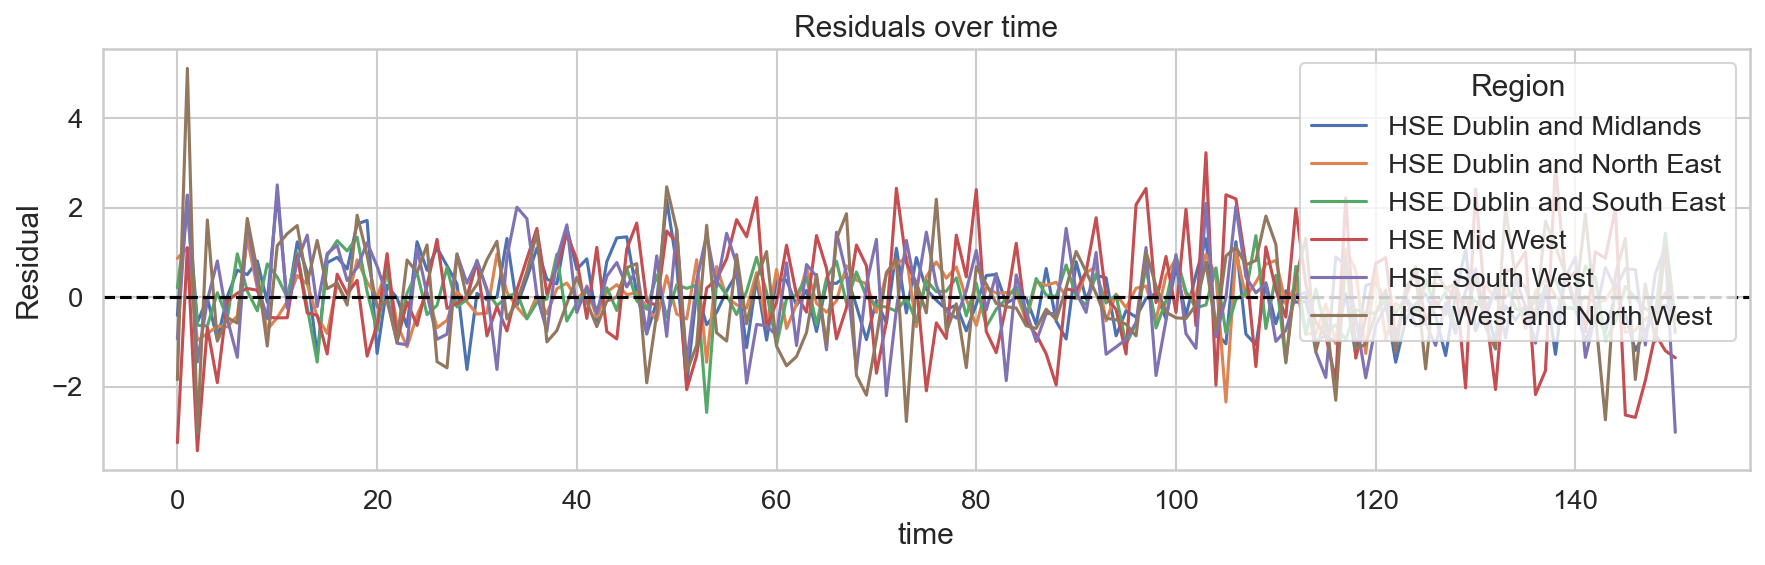

In [25]:
# Residuals plot
df_resid = pd.DataFrame(residuals.T, columns=regions)
df_resid['time'] = range(n_weeks)
df_long = df_resid.melt(id_vars='time', var_name='Region', value_name='Residual')

plt.figure(figsize=(12, 4), dpi=150)
sns.lineplot(data=df_long, x='time', y='Residual', hue='Region')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals over time')
plt.tight_layout()

In [26]:
# Outliers
df_outliers = df_long[df_long['Residual'].abs() > 3]
df_outliers

,time,Region,Residual
453,0,HSE Mid West,-3.253210
455,2,HSE Mid West,-3.433671
556,103,HSE Mid West,3.224698
754,150,HSE South West,-3.021799
756,1,HSE West and North West,5.107127
757,2,HSE West and North West,-3.054660


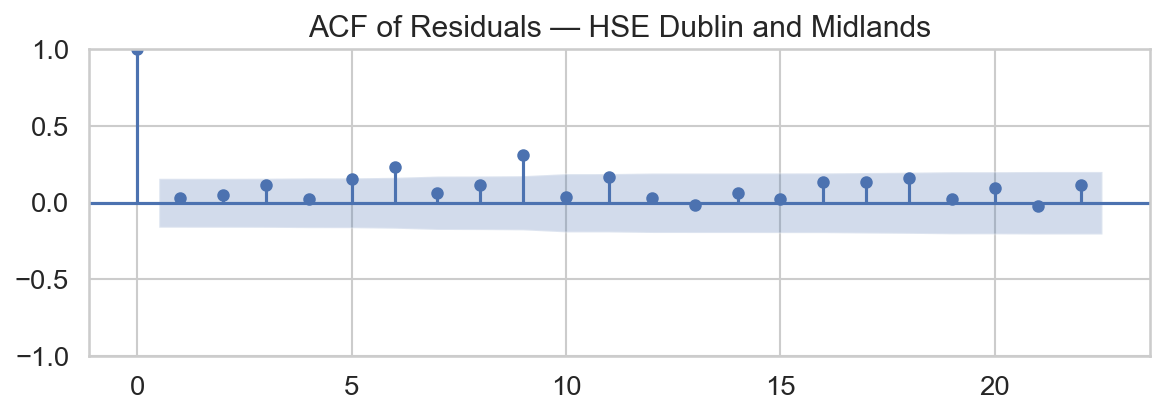

In [27]:
# ACF of residuals (first region)
fig, ax = plt.subplots(figsize=(8, 3), dpi=150)
plot_acf(residuals[0], ax=ax, title=f'ACF of Residuals \u2014 {regions[0]}')
plt.tight_layout()

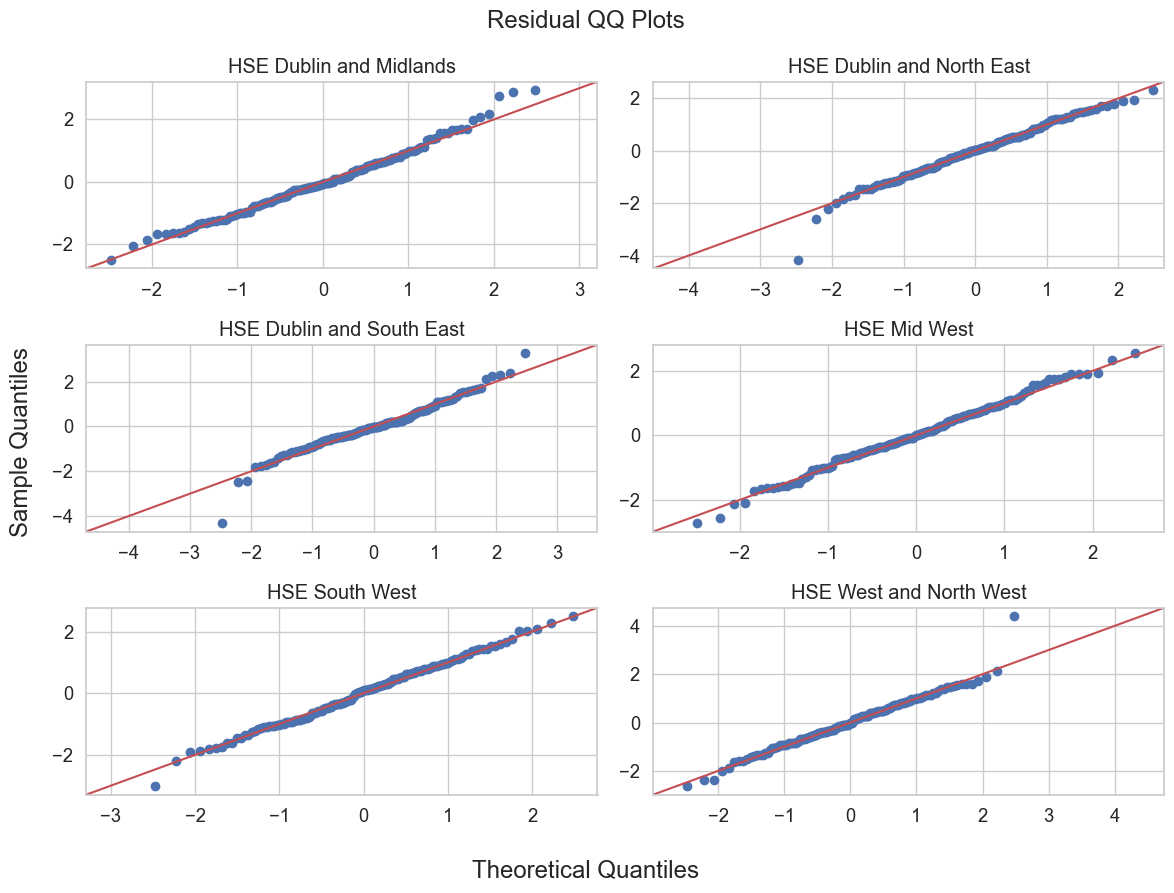

In [28]:
# QQ plots
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
for i, (ax, region) in enumerate(zip(axes.flatten(), regions)):
    std_resid = residuals[i] / residuals[i].std()
    qqplot(std_resid, line='45', ax=ax)
    ax.set_title(region)
    ax.set_xlabel('')
    ax.set_ylabel('')
fig.suptitle('Residual QQ Plots')
fig.supxlabel('Theoretical Quantiles')
fig.supylabel('Sample Quantiles')
plt.tight_layout()

## Check Convergence

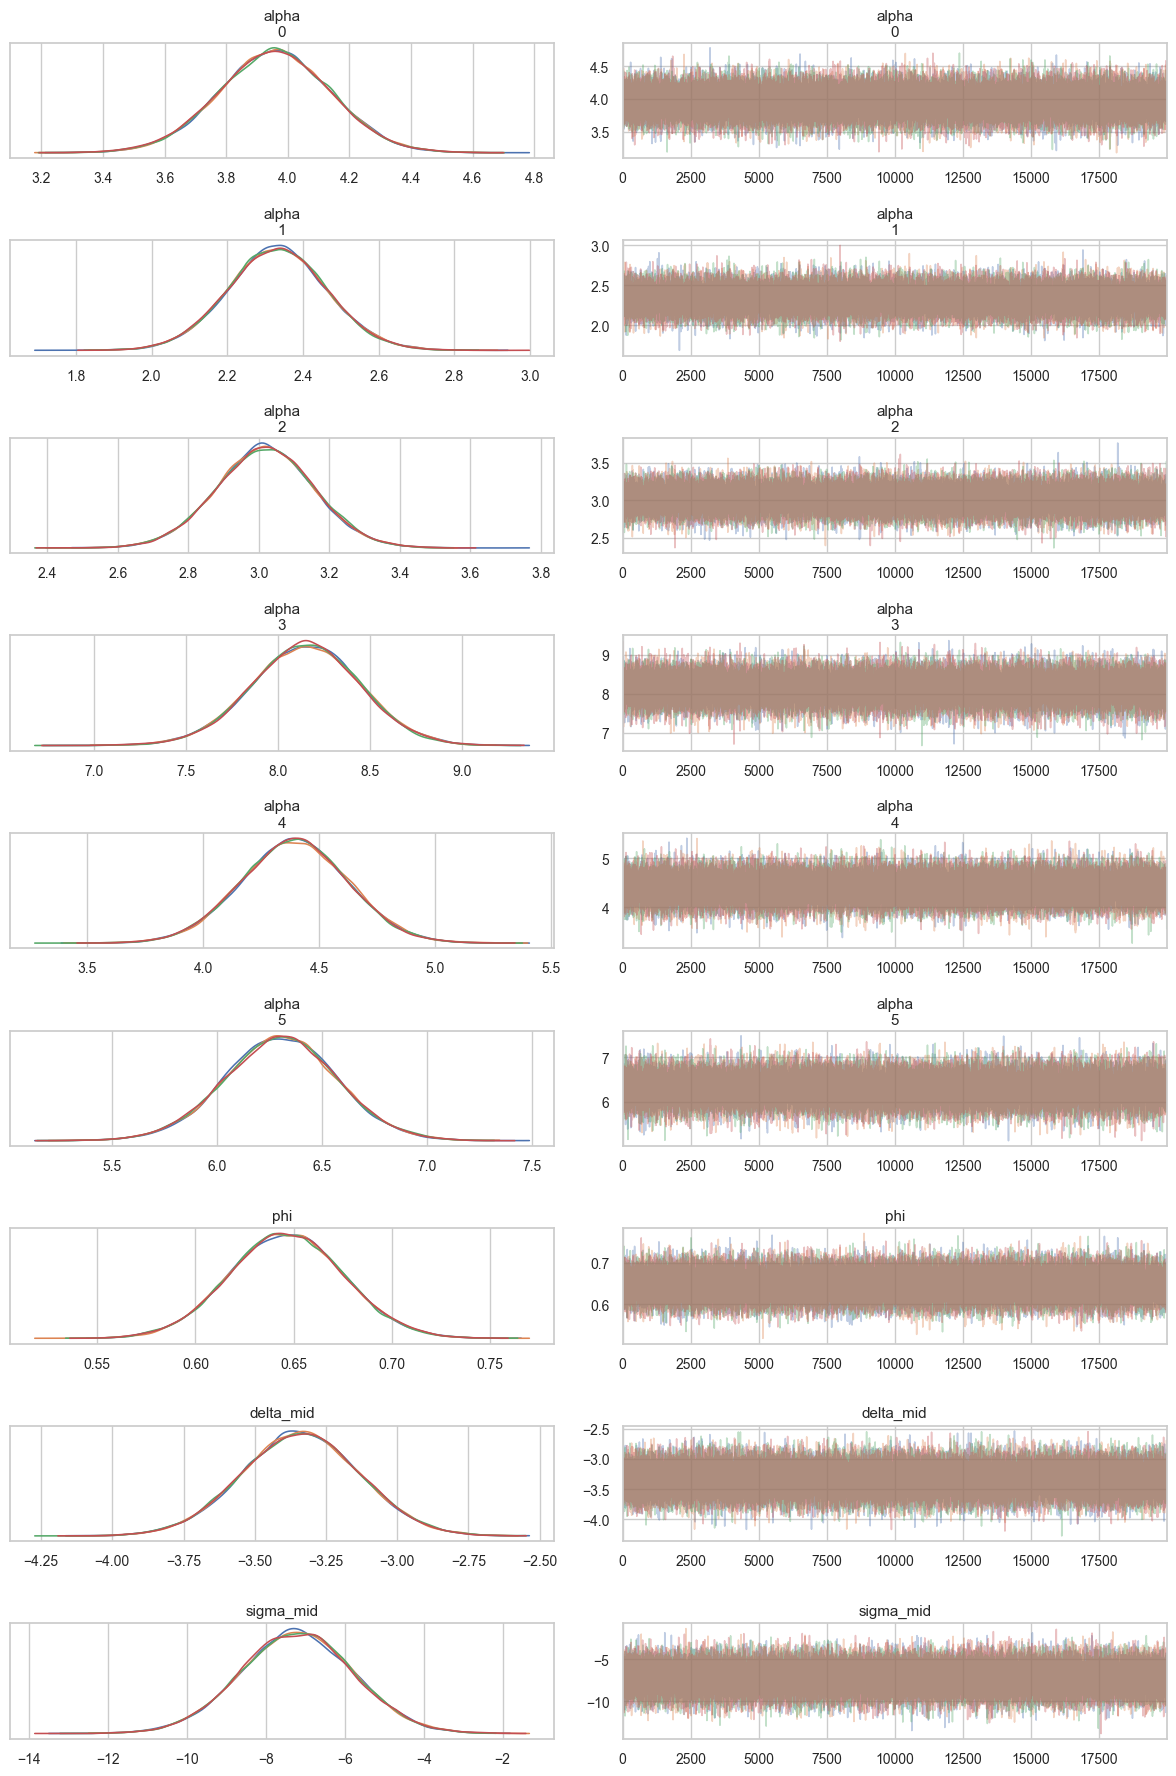

In [29]:
az.plot_trace(trace, var_names=['alpha','phi','delta_mid','sigma_mid'], compact=False)
plt.tight_layout()

### Gelman-Rubin (R-hat)

In [30]:
rhat = az.rhat(trace, var_names=all_params)

rhat_rows = []
for var in rhat.data_vars:
    vals = rhat[var].values
    if vals.ndim == 0:
        rhat_rows.append({'parameter': var, 'rhat': float(vals)})
    else:
        for j, v in enumerate(vals):
            rhat_rows.append({'parameter': f'{var}[{j+1}]', 'rhat': float(v)})

df_rhat = pd.DataFrame(rhat_rows)
print(df_rhat.to_string(index=False))
print(f'\nMax R-hat: {df_rhat["rhat"].max():.4f}')

 parameter     rhat
  alpha[1] 1.000140
  alpha[2] 1.000138
  alpha[3] 1.000079
  alpha[4] 1.000077
  alpha[5] 1.000162
  alpha[6] 1.000062
   beta[1] 1.000013
   beta[2] 1.000008
   beta[3] 1.000141
   beta[4] 1.000033
   beta[5] 1.000091
   beta[6] 1.000163
  gamma[1] 1.000226
  gamma[2] 1.000018
  gamma[3] 1.000111
  gamma[4] 1.000035
  gamma[5] 1.000154
  gamma[6] 1.000124
    tau[1] 0.999985
    tau[2] 1.000065
    tau[3] 1.000045
    tau[4] 1.000004
    tau[5] 1.000093
    tau[6] 1.000028
       phi 1.000031
 delta_pre 1.000068
 delta_mid 1.000000
delta_post 0.999995
 sigma_pre 1.000103
 sigma_mid 1.000013
sigma_post 1.000032

Max R-hat: 1.0002


## Model Comparison Criteria

WAIC via ArviZ (built-in), plus DIC via variance-based formula (Gelman et al. 2004) for comparison with JAGS output.

In [31]:
# --- WAIC (built-in) ---
waic_result = az.waic(trace)
print(waic_result)

# --- DIC (variance-based, for JAGS comparison) ---
# Uses pointwise log-likelihood already stored by pm.sample()
log_lik = trace.log_likelihood['y']
# Sum over observation dims to get total log p(y|theta) per draw
obs_dims = [d for d in log_lik.dims if d not in ('chain', 'draw')]
total_ll = log_lik.sum(dim=obs_dims)
deviance = -2 * total_ll.values.flatten()

D_bar = deviance.mean()
pDIC  = 0.5 * deviance.var()   # variance-based pDIC (Gelman 2004)
DIC   = D_bar + pDIC

print(f'\nDIC (variance-based):')
print(f'  D_bar (mean deviance): {D_bar:.2f}')
print(f'  pDIC (eff. params):    {pDIC:.2f}')
print(f'  DIC:                   {DIC:.2f}')

Computed from 80000 posterior samples and 906 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1181.45    28.39
p_waic       40.26        -

There has been a warning during the calculation. Please check the results.

DIC (variance-based):
  D_bar (mean deviance): 2318.63
  pDIC (eff. params):    35.68
  DIC:                   2354.31


/Users/fluffypony/Library/Mobile Documents/com~apple~CloudDocs/Documents/Galway/PROJECT/CODE/venv/lib/python3.14/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


## Save

In [32]:
if save_output:
    # Raw samples
    post_stacked = trace.posterior.stack(sample=('chain','draw'))
    samples = {}
    for var in all_params:
        vals = post_stacked[var].values
        if vals.ndim == 1:
            samples[var] = vals
        else:
            for j in range(vals.shape[0]):
                samples[f'{var}[{j+1}]'] = vals[j]
    pd.DataFrame(samples).to_csv(
        os.path.join(output_folder, 'raw_samples.csv'),
        index=False)

    # Fitted values (Region, time, fitted) — matches R output
    fitted_rows = []
    for i, region in enumerate(regions):
        for t in range(n_weeks):
            fitted_rows.append({
                'Region': region,
                'time': t + 1,
                'fitted': round(fullmod_hat[i, t], 4),
            })
    pd.DataFrame(fitted_rows).to_csv(
        os.path.join(output_folder, 'fitted.csv'),
        index=False)

    # DIC (variance-based, for JAGS comparison)
    pd.DataFrame([{
        'deviance': round(D_bar, 2),
        'penalty':  round(pDIC, 2),
        'DIC':      round(DIC, 2),
    }]).to_csv(
        os.path.join(output_folder, 'dic.csv'),
        index=False)

    # WAIC
    pd.DataFrame([{
        'elpd_waic': round(waic_result.elpd_waic, 2),
        'se':        round(waic_result.se, 2),
        'p_waic':    round(waic_result.p_waic, 2),
        'waic':      round(-2 * waic_result.elpd_waic, 2),
    }]).to_csv(
        os.path.join(output_folder, 'waic.csv'),
        index=False)

    # Gelman
    df_rhat.to_csv(
        os.path.join(output_folder, 'gelman.csv'),
        index=False)

    print(f'Saved to {output_folder}')

Saved to ../../data/models/v2_pymc/
